#  Feature Selection & Model Training

This notebook focuses on selecting the most relevant features and training machine learning models for prediction tasks.

###  Objectives

Build models to predict:

- Best Delivery App (Classification)
- Net Profit (Regression)

### Workflow Covered

- Importing required libraries  
- Loading processed dataset  
- Categorical encoding  
- Feature selection  
- Train-test split  
- Feature scaling  
- Classification model training  
- Regression model training  
- Model evaluation using performance metrics

### Expected Outcome

Identify the most useful features and build accurate models for smart delivery app recommendation and profit prediction.

## Importing Required Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report,
                             mean_absolute_error,
                             mean_squared_error,
                             r2_score)

print("All libraries imported successfully")

All libraries imported successfully


## Loading Processed Dataset

In this step, the cleaned and processed dataset is loaded from the project directory for further analysis and model training.

In [25]:
df = pd.read_csv('../data/processed/gigsmart_dataset.csv')
print("Dataset loaded")
print("Shape:", df.shape)
df.head(3)

Dataset loaded
Shape: (45593, 16)


,hour,day_of_week,is_weekend,is_festival,weather,zone_type,is_lunch_time,is_dinner_time,distance_km,estimated_time_min,app_name,expected_payout,fuel_cost,time_cost,net_profit,best_app
0,11,5,1,0,clear,normal,0,0,4.2,24,Swiggy,101.55,21.0,36.0,44.55,Swiggy
1,19,4,0,0,rain,low,0,1,14.5,33,Blinkit,220.01,72.5,49.5,98.01,Swiggy
2,8,5,1,0,fog,normal,0,0,6.4,26,Blinkit,104.92,32.0,39.0,33.92,Swiggy


## Categorical Encoding

In this step, categorical columns were converted into numerical format so that machine learning algorithms can process the dataset efficiently.

## One-Hot Encoding Applied On:

- weather
- zone_type

Separate binary columns were created such as:

- weather_clear
- weather_fog
- weather_rain
- zone_low
- zone_normal

## Label Encoding Applied On Target Variable:

- best_app

Delivery app names were converted into numeric labels:

- Blinkit → 0  
- Swiggy → 1  
- Zomato → 2

In [26]:
# One Hot Encoding — weather and zone_type
df_encoded = pd.get_dummies(
    df,
    columns=['weather', 'zone_type'],
    prefix=['weather', 'zone']
)

# Target variable encoded
le_target = LabelEncoder()
df_encoded['best_app'] = le_target.fit_transform(df['best_app'])

print("Target classes:", le_target.classes_)
print("Encoded target classes:", le_target.transform(le_target.classes_))
# Blinkit=0, Swiggy=1, Zomato=2

print("\nEncoding done")
print("Shape after encoding:", df_encoded.shape)
print("Columns:", df_encoded.columns.tolist())

Target classes: ['Blinkit' 'Swiggy' 'Zomato']
Encoded target classes: [0 1 2]

Encoding done
Shape after encoding: (45593, 20)
Columns: ['hour', 'day_of_week', 'is_weekend', 'is_festival', 'is_lunch_time', 'is_dinner_time', 'distance_km', 'estimated_time_min', 'app_name', 'expected_payout', 'fuel_cost', 'time_cost', 'net_profit', 'best_app', 'weather_clear', 'weather_fog', 'weather_rain', 'zone_busy', 'zone_low', 'zone_normal']


## Final Feature Selection for Classification & Regression

## Classification Features (`X_class`)

Selected features used to predict **best_app**:

- Time-based features: `hour`, `day_of_week`, `is_weekend`
- Demand features: `is_festival`, `is_lunch_time`, `is_dinner_time`
- Distance features: `distance_km`, `estimated_time_min`
- Weather encoded features
- Zone encoded features

## Removed from Classification

- `app_name` → Direct leakage risk  
- `expected_payout`, `fuel_cost`, `time_cost` → Profit-related leakage  
- `net_profit` → Separate regression target

## Removed from Regression

- `expected_payout`, `fuel_cost`, `time_cost` → Direct formula dependency  
- `app_name`, `best_app` → Categorical target leakage

## Targets Defined

- `y_class = best_app`
- `y_reg = net_profit`


In [27]:
# CLASSIFICATION FEATURES

class_features = [
    'hour', 'day_of_week', 'is_weekend',
    'is_festival', 'is_lunch_time', 'is_dinner_time',
    'distance_km', 'estimated_time_min',
    'weather_clear', 'weather_fog', 'weather_rain',
    'zone_busy', 'zone_low', 'zone_normal'
]

# REGRESSION FEATURES

reg_features = [
    'hour', 'day_of_week', 'is_weekend',
    'is_festival', 'is_lunch_time', 'is_dinner_time',
    'distance_km', 'estimated_time_min',
    'weather_clear', 'weather_fog', 'weather_rain',
    'zone_busy', 'zone_low', 'zone_normal'
]

# Features and targets set 
X_class = df_encoded[class_features]
y_class = df_encoded['best_app']

X_reg = df_encoded[reg_features]
y_reg = df_encoded['net_profit']

print("Classification features:", X_class.columns.tolist())
print("Regression features:", X_reg.columns.tolist())
print("\nClassification target distribution:")
print(y_class.value_counts())
print("\nRegression target stats:")
print(y_reg.describe().round(2))

Classification features: ['hour', 'day_of_week', 'is_weekend', 'is_festival', 'is_lunch_time', 'is_dinner_time', 'distance_km', 'estimated_time_min', 'weather_clear', 'weather_fog', 'weather_rain', 'zone_busy', 'zone_low', 'zone_normal']
Regression features: ['hour', 'day_of_week', 'is_weekend', 'is_festival', 'is_lunch_time', 'is_dinner_time', 'distance_km', 'estimated_time_min', 'weather_clear', 'weather_fog', 'weather_rain', 'zone_busy', 'zone_low', 'zone_normal']

Classification target distribution:
best_app
0    16007
2    15794
1    13792
Name: count, dtype: int64

Regression target stats:
count    45593.00
mean        43.54
std         26.40
min        -28.90
25%         24.51
50%         41.48
75%         60.99
max        134.97
Name: net_profit, dtype: float64


## Train-Test Split

The dataset was divided into:

- **80% Training Data** → used to train the models  
- **20% Testing Data** → used to evaluate performance  

`stratify=y_class` was used in classification to maintain balanced class distribution.

`random_state=42` ensures consistent results.

In [28]:
# Classification split — 80/20
X_train_class, X_test_class, \
y_train_class, y_test_class = train_test_split(
    X_class, y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

# Regression split — 80/20
X_train_reg, X_test_reg, \
y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg,
    test_size=0.20,
    random_state=42
)

print("Classification Split:")
print(f"Train: {X_train_class.shape}")
print(f"Test : {X_test_class.shape}")
print("\nRegression Split:")
print(f"Train: {X_train_reg.shape}")
print(f"Test : {X_test_reg.shape}")

Classification Split:
Train: (36474, 14)
Test : (9119, 14)

Regression Split:
Train: (36474, 14)
Test : (9119, 14)


##  Feature Scaling

`StandardScaler` was applied to standardize feature values for both classification and regression datasets.

- Mean centered to **0**
- Standard deviation scaled to **1**


In [29]:
scaler = StandardScaler()

# Classification scaling
X_train_class_scaled = scaler.fit_transform(X_train_class)
X_test_class_scaled  = scaler.transform(X_test_class)

# Regression scaling
X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled  = scaler.transform(X_test_reg)

print("Scaling done")

Scaling done


## Classification Model Training

Three classification models were trained to predict the **best delivery app**:

- Logistic Regression  
- Decision Tree Classifier  
- Random Forest Classifier  

## Evaluation Metrics

Models were evaluated using:

- Accuracy  
- Precision  
- Recall  
- F1 Score  

In [30]:


clf_results = {}

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_class_scaled, y_train_class)
y_pred_lr = lr.predict(X_test_class_scaled)

clf_results['Logistic Regression'] = {
    'Accuracy' : accuracy_score(y_test_class, y_pred_lr),
    'Precision': precision_score(y_test_class, y_pred_lr,
                                  average='weighted',
                                  zero_division=0),
    'Recall'   : recall_score(y_test_class, y_pred_lr,
                               average='weighted'),
    'F1 Score' : f1_score(y_test_class, y_pred_lr,
                           average='weighted')
}

# 2. Decision Tree
dt_clf = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
dt_clf.fit(X_train_class, y_train_class)
y_pred_dt = dt_clf.predict(X_test_class)

clf_results['Decision Tree'] = {
    'Accuracy' : accuracy_score(y_test_class, y_pred_dt),
    'Precision': precision_score(y_test_class, y_pred_dt,
                                  average='weighted',
                                  zero_division=0),
    'Recall'   : recall_score(y_test_class, y_pred_dt,
                               average='weighted'),
    'F1 Score' : f1_score(y_test_class, y_pred_dt,
                           average='weighted')
}

# 3. Random Forest
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf_clf.fit(X_train_class, y_train_class)
y_pred_rf = rf_clf.predict(X_test_class)

clf_results['Random Forest'] = {
    'Accuracy' : accuracy_score(y_test_class, y_pred_rf),
    'Precision': precision_score(y_test_class, y_pred_rf,
                                  average='weighted',
                                  zero_division=0),
    'Recall'   : recall_score(y_test_class, y_pred_rf,
                               average='weighted'),
    'F1 Score' : f1_score(y_test_class, y_pred_rf,
                           average='weighted')
}

clf_df = pd.DataFrame(clf_results).T.round(4)
print("CLASSIFICATION RESULTS")
print(clf_df)

CLASSIFICATION RESULTS
                     Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.9999     0.9999  0.9999    0.9999
Decision Tree          0.9732     0.9750  0.9732    0.9733
Random Forest          0.9887     0.9889  0.9887    0.9887


## Regression Model Training

Three regression models were trained to predict **net_profit**:

- Linear Regression  
- Decision Tree Regressor  
- Random Forest Regressor  

## Evaluation Metrics

Models were evaluated using:

- MAE (Mean Absolute Error)  
- RMSE (Root Mean Squared Error)  
- R² Score  


In [31]:

reg_results = {}

# 1. Linear Regression 
lin_reg = LinearRegression()
lin_reg.fit(X_train_reg_scaled, y_train_reg)
y_pred_lin = lin_reg.predict(X_test_reg_scaled)

reg_results['Linear Regression'] = {
    'MAE' : mean_absolute_error(y_test_reg, y_pred_lin),
    'RMSE': np.sqrt(mean_squared_error(y_test_reg, y_pred_lin)),
    'R2'  : r2_score(y_test_reg, y_pred_lin)
}

# 2. Decision Tree Regressor
dt_reg = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
dt_reg.fit(X_train_reg, y_train_reg)
y_pred_dt_reg = dt_reg.predict(X_test_reg)

reg_results['Decision Tree'] = {
    'MAE' : mean_absolute_error(y_test_reg, y_pred_dt_reg),
    'RMSE': np.sqrt(mean_squared_error(y_test_reg,
                                        y_pred_dt_reg)),
    'R2'  : r2_score(y_test_reg, y_pred_dt_reg)
}

# 3. Random Forest Regressor
rf_reg = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
rf_reg.fit(X_train_reg, y_train_reg)
y_pred_rf_reg = rf_reg.predict(X_test_reg)

reg_results['Random Forest'] = {
    'MAE' : mean_absolute_error(y_test_reg, y_pred_rf_reg),
    'RMSE': np.sqrt(mean_squared_error(y_test_reg,
                                        y_pred_rf_reg)),
    'R2'  : r2_score(y_test_reg, y_pred_rf_reg)
}


reg_df = pd.DataFrame(reg_results).T.round(4)
print("REGRESSION RESULTS")
print(reg_df)

REGRESSION RESULTS
                      MAE    RMSE      R2
Linear Regression  4.4878  5.3192  0.9594
Decision Tree      2.4645  3.6316  0.9811
Random Forest      1.8409  2.9578  0.9874


## Cross Validation (5-Fold)

5-Fold Cross Validation was applied to check model stability and reliability on different data splits.

In [32]:
from sklearn.model_selection import cross_val_score
print("CROSS VALIDATION RESULTS (5-Fold)")
# Classification CV
models_clf = {
    'Logistic Regression': lr,
    'Decision Tree'      : dt_clf,
    'Random Forest'      : rf_clf
}

print("\nClassification (best_app):")
for name, model in models_clf.items():
    if name == 'Logistic Regression':
        scores = cross_val_score(
            model, X_class, y_class,
            cv=5, scoring='accuracy'
        )
    else:
        scores = cross_val_score(
            model, X_class, y_class,
            cv=5, scoring='accuracy'
        )
    print(f"{name}:")
    print(f"  Scores : {scores.round(4)}")
    print(f"  Mean   : {scores.mean():.4f}")
    print(f"  Std Dev: {scores.std():.4f}")

# Regression CV
models_reg = {
    'Linear Regression': lin_reg,
    'Decision Tree'    : dt_reg,
    'Random Forest'    : rf_reg
}

print("\nRegression (net_profit):")
for name, model in models_reg.items():
    scores = cross_val_score(
        model, X_reg, y_reg,
        cv=5, scoring='r2'
    )
    print(f"{name}:")
    print(f"  Scores : {scores.round(4)}")
    print(f"  Mean   : {scores.mean():.4f}")
    print(f"  Std Dev: {scores.std():.4f}")

CROSS VALIDATION RESULTS (5-Fold)

Classification (best_app):
Logistic Regression:
  Scores : [1. 1. 1. 1. 1.]
  Mean   : 1.0000
  Std Dev: 0.0000
Decision Tree:
  Scores : [0.9718 0.9723 0.9742 0.975  0.9714]
  Mean   : 0.9729
  Std Dev: 0.0014
Random Forest:
  Scores : [0.9895 0.9911 0.9909 0.9916 0.9914]
  Mean   : 0.9909
  Std Dev: 0.0007

Regression (net_profit):
Linear Regression:
  Scores : [0.9605 0.9608 0.9619 0.96   0.9602]
  Mean   : 0.9607
  Std Dev: 0.0007
Decision Tree:
  Scores : [0.9819 0.9818 0.9823 0.9815 0.9813]
  Mean   : 0.9818
  Std Dev: 0.0003
Random Forest:
  Scores : [0.9885 0.9883 0.9888 0.988  0.9874]
  Mean   : 0.9882
  Std Dev: 0.0005


FEATURE IMPORTANCE


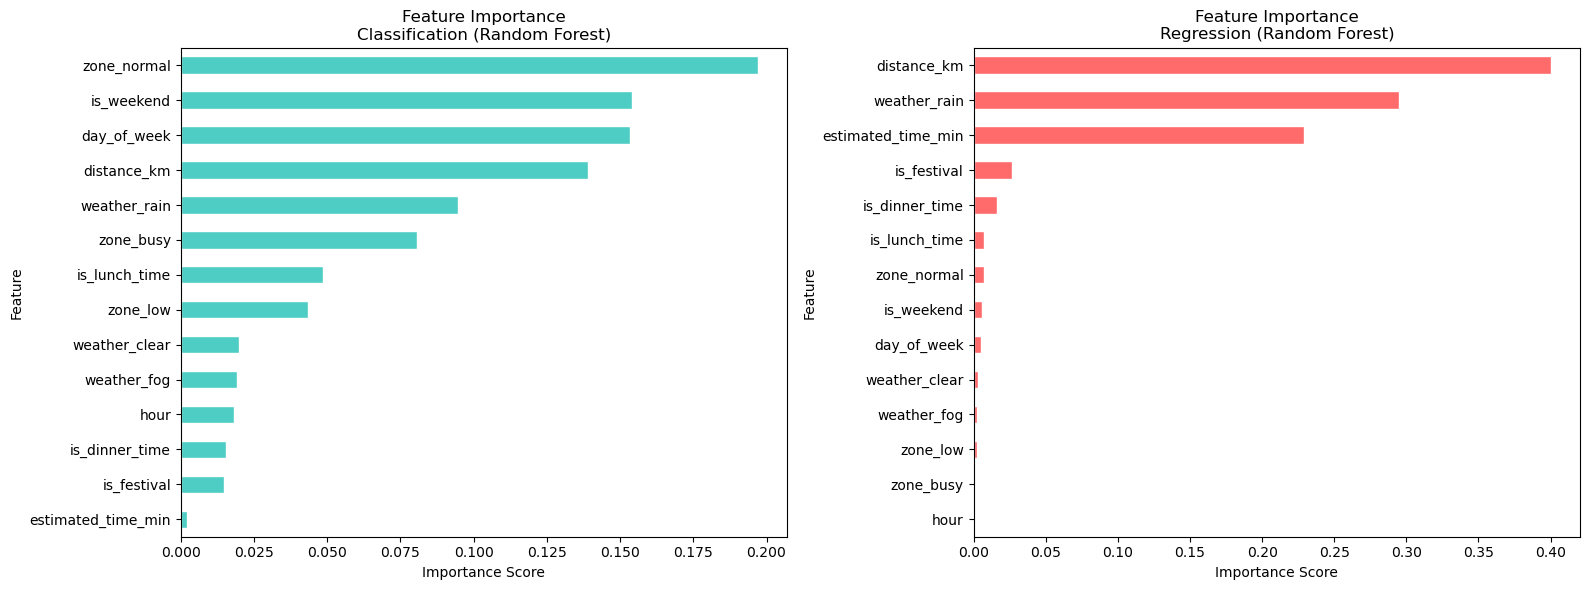


Top 5 Classification Features:
     Feature  Importance
 zone_normal    0.197150
  is_weekend    0.154026
 day_of_week    0.153335
 distance_km    0.138943
weather_rain    0.094805

Top 5 Regression Features:
           Feature  Importance
       distance_km    0.400365
      weather_rain    0.295078
estimated_time_min    0.228806
       is_festival    0.026291
    is_dinner_time    0.016244


In [33]:
print("FEATURE IMPORTANCE")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Classification — Random Forest
feat_imp_clf = pd.DataFrame({
    'Feature'   : class_features,
    'Importance': rf_clf.feature_importances_
}).sort_values('Importance', ascending=True)

feat_imp_clf.plot(
    kind='barh',
    x='Feature',
    y='Importance',
    ax=axes[0],
    color='#4ECDC4',
    edgecolor='white',
    legend=False
)
axes[0].set_title(
    'Feature Importance\nClassification (Random Forest)'
)
axes[0].set_xlabel('Importance Score')

# Regression — Random Forest
feat_imp_reg = pd.DataFrame({
    'Feature'   : reg_features,
    'Importance': rf_reg.feature_importances_
}).sort_values('Importance', ascending=True)

feat_imp_reg.plot(
    kind='barh',
    x='Feature',
    y='Importance',
    ax=axes[1],
    color='#FF6B6B',
    edgecolor='white',
    legend=False
)
axes[1].set_title(
    'Feature Importance\nRegression (Random Forest)'
)
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

print("\nTop 5 Classification Features:")
print(feat_imp_clf.sort_values(
    'Importance', ascending=False
).head(5).to_string(index=False))

print("\nTop 5 Regression Features:")
print(feat_imp_reg.sort_values(
    'Importance', ascending=False
).head(5).to_string(index=False))

## Feature Importance Analysis

Random Forest feature importance was used to identify the most influential features for both tasks.

## Top Classification Features

- zone_normal  
- day_of_week  
- is_weekend  
- weather_rain  
- distance_km  

These features strongly affect the prediction of the best delivery app.

## Top Regression Features

- distance_km  
- weather_rain  
- estimated_time_min  
- is_festival  
- is_dinner_time  

These features have the highest impact on net profit prediction.

## Observation

Location, timing, weather, and travel distance are the key drivers for both app recommendation and profit estimation.